<a href="https://colab.research.google.com/github/amankiitg/5DParallel/blob/main/tensor_parallelism_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Tensor Parallelism: Hands-On Tutorial

**A complete, runnable demonstration of Tensor Parallelism applied to an LLM architecture.**

This notebook:
1. Implements a GPT-style transformer model from scratch
2. Implements Column-Parallel and Row-Parallel linear layers from scratch
3. Benchmarks **without TP** (single GPU) vs **with TP** (multi-GPU)
4. Compares memory usage, throughput, and verifies numerical correctness

**Requirements:** 2+ NVIDIA GPUs (RunPod, Lambda, etc.)

---

## Part 0: Environment Setup

In [ ]:
!nvidia-smi --query-gpu=index,name,memory.total --format=csv,noheader
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Number of GPUs: {torch.cuda.device_count()}')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} '
          f'({torch.cuda.get_device_properties(i).total_mem / 1e9:.1f} GB)')

0, NVIDIA H200, 143771 MiB
1, NVIDIA H200, 143771 MiB
PyTorch version: 2.4.1+cu124
CUDA available: True
Number of GPUs: 2


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

## Part 1: The Model — A GPT-Style Transformer

We define a standard transformer decoder with:
- `d_model = 512`, `n_heads = 8`, `d_head = 64`
- `d_ff = 2048` (4x expansion), `n_layers = 6`, `vocab_size = 10000`

Small enough to run quickly but large enough to see real differences.

In [ ]:
# Write the shared model definition
with open("model_shared.py", "w") as f:
    f.write('''
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, json, time

D_MODEL = 512
N_HEADS = 8
D_HEAD = D_MODEL // N_HEADS
D_FF = 2048
N_LAYERS = 6
VOCAB_SIZE = 10000
MAX_SEQ_LEN = 512
BATCH_SIZE = 8
SEQ_LEN = 256
NUM_WARMUP = 3
NUM_BENCHMARK = 10

class StandardAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.scale = 1.0 / math.sqrt(self.d_head)

    def forward(self, x):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        attn = (Q @ K.transpose(-2, -1)) * self.scale
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(mask, float("-inf"))
        attn = F.softmax(attn, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(out)

class StandardFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.W1 = nn.Linear(d_model, d_ff)
        self.W2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.W2(F.gelu(self.W1(x)))

class StandardTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = StandardAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = StandardFFN(d_model, d_ff)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

class StandardGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_emb = nn.Embedding(MAX_SEQ_LEN, D_MODEL)
        self.blocks = nn.ModuleList([
            StandardTransformerBlock(D_MODEL, N_HEADS, D_FF) for _ in range(N_LAYERS)
        ])
        self.ln_f = nn.LayerNorm(D_MODEL)
        self.lm_head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)
    def forward(self, input_ids):
        B, T = input_ids.shape
        pos = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.lm_head(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())
def get_gpu_memory_mb(device=0):
    return torch.cuda.memory_allocated(device) / 1024 / 1024
def get_gpu_peak_memory_mb(device=0):
    return torch.cuda.max_memory_allocated(device) / 1024 / 1024
''')
print("model_shared.py written.")

model_shared.py written.


Let's verify the model works:

In [ ]:
from model_shared import *

model = StandardGPT().cuda()
n_params = count_parameters(model)
print(f'Model parameters: {n_params:,} ({n_params * 2 / 1e6:.1f} MB in BF16)')
print(f'Architecture: d_model={D_MODEL}, n_heads={N_HEADS}, d_ff={D_FF}, layers={N_LAYERS}')
print(f'\nBlock 0 parameter breakdown:')
for name, param in model.named_parameters():
    if 'blocks.0.' in name:
        print(f'  {name:40s} {str(list(param.shape)):20s} {param.numel():>8,}')

test_input = torch.randint(0, VOCAB_SIZE, (2, 32)).cuda()
with torch.no_grad():
    out = model(test_input)
print(f'\nForward pass OK: {list(test_input.shape)} -> {list(out.shape)}')
del model; torch.cuda.empty_cache()

Model parameters: 29,405,184 (58.8 MB in BF16)
Architecture: d_model=512, n_heads=8, d_ff=2048, layers=6

Block 0 parameter breakdown:
  blocks.0.ln1.weight                      [512]                     512
  blocks.0.ln1.bias                        [512]                     512
  blocks.0.attn.W_q.weight                 [512, 512]            262,144
  blocks.0.attn.W_k.weight                 [512, 512]            262,144
  blocks.0.attn.W_v.weight                 [512, 512]            262,144
  blocks.0.attn.W_o.weight                 [512, 512]            262,144
  blocks.0.ln2.weight                      [512]                     512
  blocks.0.ln2.bias                        [512]                     512
  blocks.0.ffn.W1.weight                   [2048, 512]          1,048,576
  blocks.0.ffn.W1.bias                     [2048]                  2,048
  blocks.0.ffn.W2.weight                   [512, 2048]          1,048,576
  blocks.0.ffn.W2.bias                     [512]            

## Part 2: Baseline — No Tensor Parallelism (Single GPU)

Run the full model on a single GPU and measure memory + throughput.

In [ ]:
# Write baseline benchmark script
with open("benchmark_no_tp.py", "w") as f:
    f.write('''
import torch, torch.nn as nn, time, json, sys
sys.path.insert(0, ".")
from model_shared import *

def main():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
    torch.cuda.reset_peak_memory_stats(device)
    torch.manual_seed(42)

    model = StandardGPT().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    mem_model = get_gpu_memory_mb(device)
    n_params = count_parameters(model)

    torch.manual_seed(123)
    input_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN), device=device)
    labels = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN), device=device)

    for _ in range(NUM_WARMUP):
        logits = model(input_ids)
        loss = nn.functional.cross_entropy(logits.view(-1, VOCAB_SIZE), labels.view(-1))
        loss.backward(); optimizer.step(); optimizer.zero_grad()

    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize()

    fwd_t, bwd_t, step_t = [], [], []
    for _ in range(NUM_BENCHMARK):
        optimizer.zero_grad()
        torch.cuda.synchronize(); t0 = time.perf_counter()
        logits = model(input_ids)
        loss = nn.functional.cross_entropy(logits.view(-1, VOCAB_SIZE), labels.view(-1))
        torch.cuda.synchronize(); t1 = time.perf_counter()
        loss.backward()
        torch.cuda.synchronize(); t2 = time.perf_counter()
        optimizer.step()
        torch.cuda.synchronize(); t3 = time.perf_counter()
        fwd_t.append(t1-t0); bwd_t.append(t2-t1); step_t.append(t3-t0)

    peak = get_gpu_peak_memory_mb(device)
    avg = lambda lst: sum(lst)/len(lst)

    results = dict(mode="no_tp", num_gpus=1, total_params=n_params, params_per_gpu=n_params,
        mem_model_mb=round(mem_model, 2), mem_peak_mb=round(peak, 2),
        fwd_ms=round(avg(fwd_t)*1000, 3), bwd_ms=round(avg(bwd_t)*1000, 3),
        step_ms=round(avg(step_t)*1000, 3),
        tokens_per_sec=round(BATCH_SIZE*SEQ_LEN/avg(step_t), 1),
        loss=round(loss.item(), 4))

    with open("results_no_tp.json", "w") as fout:
        json.dump(results, fout, indent=2)

    print("\\n" + "="*60)
    print("  BASELINE (No Tensor Parallelism) - 1 GPU")
    print("="*60)
    for k in ["params_per_gpu","mem_model_mb","mem_peak_mb","fwd_ms","bwd_ms","step_ms","tokens_per_sec","loss"]:
        v = results[k]
        label = k.replace("_"," ").title()
        if isinstance(v, float):
            print(f"  {label:<25} {v:>12.2f}")
        else:
            print(f"  {label:<25} {v:>12,}")
    print("="*60)

if __name__ == "__main__":
    main()
''')
print("benchmark_no_tp.py written.")

benchmark_no_tp.py written.


In [ ]:
!python benchmark_no_tp.py


  BASELINE (No Tensor Parallelism) - 1 GPU
  Params Per Gpu              29,405,184
  Mem Model Mb                    113.11
  Mem Peak Mb                    1204.44
  Fwd Ms                            3.95
  Bwd Ms                            6.85
  Step Ms                          11.84
  Tokens Per Sec               173022.90
  Loss                              7.58


## Part 3: Tensor Parallelism — From Scratch

### Column-Parallel Linear
Split weight **columns** (output dim). Each GPU computes a slice. **No communication.**

### Row-Parallel Linear
Split weight **rows** (input dim). Each GPU computes a partial sum. **All-reduce needed!**

### Pattern in Transformer Block
```
Attention:  W_q, W_k, W_v → Column-Parallel (split heads across GPUs)
            W_o            → Row-Parallel    (combine heads, ALL-REDUCE)

FFN:        W1             → Column-Parallel (split d_ff across GPUs)
            W2             → Row-Parallel    (combine back, ALL-REDUCE)

Communication: 2 all-reduces per transformer block
```

In [ ]:
# Write the Tensor Parallel benchmark script
with open("benchmark_tp.py", "w") as f:
    f.write('''
import torch, torch.nn as nn, torch.nn.functional as F
import torch.distributed as dist
import math, time, json, os, sys
sys.path.insert(0, ".")
from model_shared import (D_MODEL, N_HEADS, D_HEAD, D_FF, N_LAYERS, VOCAB_SIZE,
    MAX_SEQ_LEN, BATCH_SIZE, SEQ_LEN, NUM_WARMUP, NUM_BENCHMARK,
    count_parameters, get_gpu_memory_mb, get_gpu_peak_memory_mb)

# ================================================================
#  AUTOGRAD FUNCTIONS FOR TP COMMUNICATION
# ================================================================
# _CopyToParallelRegion:    identity forward,   all-reduce backward
#   -> Used BEFORE column-parallel layers
# _ReduceFromParallelRegion: all-reduce forward, identity backward
#   -> Used AFTER row-parallel layers

class _CopyToParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return x
    @staticmethod
    def backward(ctx, grad):
        dist.all_reduce(grad, op=dist.ReduceOp.SUM)
        return grad

class _ReduceFromParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        dist.all_reduce(x, op=dist.ReduceOp.SUM)
        return x
    @staticmethod
    def backward(ctx, grad):
        return grad

# ================================================================
#  COLUMN-PARALLEL LINEAR
# ================================================================
# Full: (d_in, d_out) -> This GPU: (d_in, d_out // N)
# Input: same on all GPUs -> Output: each GPU gets different slice
# NO communication in forward!

class ColumnParallelLinear(nn.Module):
    def __init__(self, d_in, d_out, bias=True):
        super().__init__()
        ws = dist.get_world_size()
        assert d_out % ws == 0
        self.d_out_local = d_out // ws
        self.weight = nn.Parameter(torch.empty(self.d_out_local, d_in))
        self.bias = nn.Parameter(torch.empty(self.d_out_local)) if bias else None
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            nn.init.uniform_(self.bias, -1/math.sqrt(d_in), 1/math.sqrt(d_in))

    def forward(self, x):
        x = _CopyToParallelRegion.apply(x)
        return F.linear(x, self.weight, self.bias)

# ================================================================
#  ROW-PARALLEL LINEAR
# ================================================================
# Full: (d_in, d_out) -> This GPU: (d_in // N, d_out)
# Input: local slice -> Output: PARTIAL sum, needs ALL-REDUCE!

class RowParallelLinear(nn.Module):
    def __init__(self, d_in, d_out, bias=True):
        super().__init__()
        ws = dist.get_world_size()
        rank = dist.get_rank()
        assert d_in % ws == 0
        self.d_in_local = d_in // ws
        self.weight = nn.Parameter(torch.empty(d_out, self.d_in_local))
        self.bias = None
        if bias and rank == 0:
            self.bias = nn.Parameter(torch.empty(d_out))
            nn.init.uniform_(self.bias, -1/math.sqrt(d_in), 1/math.sqrt(d_in))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

    def forward(self, x):
        out = F.linear(x, self.weight, self.bias)
        return _ReduceFromParallelRegion.apply(out)

# ================================================================
#  TP ATTENTION (split by heads)
# ================================================================

class TPAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        ws = dist.get_world_size()
        self.n_heads_local = n_heads // ws
        self.d_head = d_model // n_heads
        self.d_local = self.n_heads_local * self.d_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.W_q = ColumnParallelLinear(d_model, d_model, bias=False)
        self.W_k = ColumnParallelLinear(d_model, d_model, bias=False)
        self.W_v = ColumnParallelLinear(d_model, d_model, bias=False)
        self.W_o = RowParallelLinear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads_local, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads_local, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads_local, self.d_head).transpose(1, 2)
        attn = (Q @ K.transpose(-2, -1)) * self.scale
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(mask, float("-inf"))
        attn = F.softmax(attn, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, T, self.d_local)
        return self.W_o(out)  # ALL-REDUCE happens here

# ================================================================
#  TP FFN
# ================================================================

class TPFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.W1 = ColumnParallelLinear(d_model, d_ff)
        self.W2 = RowParallelLinear(d_ff, d_model)
    def forward(self, x):
        return self.W2(F.gelu(self.W1(x)))  # ALL-REDUCE in W2

# ================================================================
#  TP TRANSFORMER BLOCK & FULL MODEL
# ================================================================

class TPTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)  # NOT parallelized
        self.attn = TPAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)  # NOT parallelized
        self.ffn = TPFFN(d_model, d_ff)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))  # 1 all-reduce
        x = x + self.ffn(self.ln2(x))   # 1 all-reduce
        return x  # Total: 2 all-reduces per block

class TPGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_emb = nn.Embedding(MAX_SEQ_LEN, D_MODEL)
        self.blocks = nn.ModuleList([
            TPTransformerBlock(D_MODEL, N_HEADS, D_FF) for _ in range(N_LAYERS)
        ])
        self.ln_f = nn.LayerNorm(D_MODEL)
        self.lm_head = ColumnParallelLinear(D_MODEL, VOCAB_SIZE, bias=False)
    def forward(self, input_ids):
        B, T = input_ids.shape
        pos = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.lm_head(x)

# ================================================================
#  DIFFERENTIABLE ALL-GATHER FOR TP CROSS ENTROPY
# ================================================================

class _AllGatherForTP(torch.autograd.Function):
    """all-gather forward, reduce-scatter backward."""
    @staticmethod
    def forward(ctx, x):
        ws = dist.get_world_size()
        ctx.ws = ws
        gathered = [torch.zeros_like(x) for _ in range(ws)]
        dist.all_gather(gathered, x.contiguous())
        return torch.cat(gathered, dim=-1)

    @staticmethod
    def backward(ctx, grad):
        ws = ctx.ws
        rank = dist.get_rank()
        chunks = grad.chunk(ws, dim=-1)
        return chunks[rank].contiguous()

def tp_cross_entropy(logits_local, labels, vocab_size):
    full = _AllGatherForTP.apply(logits_local)
    return F.cross_entropy(full.view(-1, vocab_size), labels.view(-1))

# ================================================================
#  MAIN
# ================================================================

def main():
    dist.init_process_group(backend="nccl")
    rank = dist.get_rank()
    ws = dist.get_world_size()
    device = torch.device(f"cuda:{rank}")
    torch.cuda.set_device(device)
    torch.cuda.reset_peak_memory_stats(device)
    torch.manual_seed(42)

    if rank == 0:
        print(f"\\nTP benchmark: {ws} GPUs", flush=True)
        print(f"  Each GPU: {N_HEADS//ws}/{N_HEADS} heads, {D_FF//ws}/{D_FF} FFN dim", flush=True)

    model = TPGPT().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    mem_model = get_gpu_memory_mb(device)
    n_local = count_parameters(model)

    torch.manual_seed(123)
    ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN), device=device)
    labels = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN), device=device)

    for _ in range(NUM_WARMUP):
        lo = model(ids)
        loss = tp_cross_entropy(lo, labels, VOCAB_SIZE)
        loss.backward(); optimizer.step(); optimizer.zero_grad()

    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize(); dist.barrier()

    fwd_t, bwd_t, step_t = [], [], []
    for _ in range(NUM_BENCHMARK):
        optimizer.zero_grad()
        torch.cuda.synchronize(); dist.barrier(); t0 = time.perf_counter()
        lo = model(ids)
        loss = tp_cross_entropy(lo, labels, VOCAB_SIZE)
        torch.cuda.synchronize(); t1 = time.perf_counter()
        loss.backward()
        torch.cuda.synchronize(); t2 = time.perf_counter()
        optimizer.step()
        torch.cuda.synchronize(); t3 = time.perf_counter()
        fwd_t.append(t1-t0); bwd_t.append(t2-t1); step_t.append(t3-t0)

    peak = get_gpu_peak_memory_mb(device)

    for r in range(ws):
        if rank == r:
            print(f"  [GPU {rank}] params: {n_local:,} | model: {mem_model:.1f} MB | peak: {peak:.1f} MB", flush=True)
        dist.barrier()

    if rank == 0:
        avg = lambda lst: sum(lst)/len(lst)
        results = dict(mode=f"tp_{ws}", num_gpus=ws, params_per_gpu=n_local,
            mem_model_mb=round(mem_model, 2), mem_peak_mb=round(peak, 2),
            fwd_ms=round(avg(fwd_t)*1000, 3), bwd_ms=round(avg(bwd_t)*1000, 3),
            step_ms=round(avg(step_t)*1000, 3),
            tokens_per_sec=round(BATCH_SIZE*SEQ_LEN/avg(step_t), 1),
            loss=round(loss.item(), 4))
        with open("results_tp.json", "w") as fout:
            json.dump(results, fout, indent=2)
        print("\\n" + "="*60)
        print(f"  TENSOR PARALLELISM - {ws} GPUs")
        print("="*60)
        for k in ["params_per_gpu","mem_model_mb","mem_peak_mb","fwd_ms","bwd_ms","step_ms","tokens_per_sec","loss"]:
            v = results[k]
            label = k.replace("_"," ").title()
            if isinstance(v, float):
                print(f"  {label:<25} {v:>12.2f}")
            else:
                print(f"  {label:<25} {v:>12,}")
        print("="*60)

    dist.destroy_process_group()

if __name__ == "__main__":
    main()
''')
print("benchmark_tp.py written.")

benchmark_tp.py written.


### Run the TP benchmark

`torchrun` launches one process per GPU. Each sees a different `dist.get_rank()`.
**Adjust `nproc_per_node` to match your GPU count.**

In [ ]:
import torch
n_gpus = min(torch.cuda.device_count(), 2)
print(f'Launching with {n_gpus} GPUs...')
!torchrun --nproc_per_node={n_gpus} benchmark_tp.py

Launching with 2 GPUs...
W0205 07:00:50.555000 137752706811008 torch/distributed/run.py:779] 
W0205 07:00:50.555000 137752706811008 torch/distributed/run.py:779] *****************************************
W0205 07:00:50.555000 137752706811008 torch/distributed/run.py:779] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0205 07:00:50.555000 137752706811008 torch/distributed/run.py:779] *****************************************

TP benchmark: 2 GPUs
  Each GPU: 4/8 heads, 1024/2048 FFN dim
  [GPU 0] params: 17,401,856 | model: 66.9 MB | peak: 837.4 MB
  [GPU 1] params: 17,398,784 | model: 66.8 MB | peak: 836.2 MB

  TENSOR PARALLELISM - 2 GPUs
  Params Per Gpu              17,401,856
  Mem Model Mb                     66.85
  Mem Peak Mb                     837.42
  Fwd Ms                            7.51
  Bwd Ms                

## Part 4: Side-by-Side Comparison

In [ ]:
import json

with open('results_no_tp.json') as f: no_tp = json.load(f)
with open('results_tp.json') as f: tp = json.load(f)

ng = tp["num_gpus"]
p1, p2 = no_tp['params_per_gpu'], tp['params_per_gpu']
m1, m2 = no_tp['mem_model_mb'], tp['mem_model_mb']
pk1, pk2 = no_tp['mem_peak_mb'], tp['mem_peak_mb']
speedup = no_tp['step_ms'] / tp['step_ms']
eff = speedup / ng * 100

print("\n" + "="*74)
print("  TENSOR PARALLELISM: SIDE-BY-SIDE COMPARISON")
print("="*74)
rows = [
    ("Parameters/GPU",     f"{p1:,}",              f"{p2:,}"),
    ("  Reduction",        "---",                   f"{(1-p2/p1)*100:.1f}% fewer"),
    ("---", "", ""),
    ("Model memory (MB)",  f"{m1:.1f}",            f"{m2:.1f}"),
    ("  Reduction",        "---",                   f"{(1-m2/m1)*100:.1f}% less"),
    ("Peak memory (MB)",   f"{pk1:.1f}",           f"{pk2:.1f}"),
    ("  Reduction",        "---",                   f"{(1-pk2/pk1)*100:.1f}% less"),
    ("---", "", ""),
    ("Forward (ms)",       f"{no_tp['fwd_ms']:.2f}",  f"{tp['fwd_ms']:.2f}"),
    ("Backward (ms)",      f"{no_tp['bwd_ms']:.2f}",  f"{tp['bwd_ms']:.2f}"),
    ("Full step (ms)",     f"{no_tp['step_ms']:.2f}",  f"{tp['step_ms']:.2f}"),
    ("  Speedup",          "---",                   f"{speedup:.2f}x"),
    ("  Ideal",            "---",                   f"{ng:.0f}x"),
    ("  Efficiency",       "---",                   f"{eff:.1f}%"),
    ("---", "", ""),
    ("Throughput (tok/s)", f"{no_tp['tokens_per_sec']:,.0f}", f"{tp['tokens_per_sec']:,.0f}"),
    ("Loss",               f"{no_tp['loss']:.4f}",  f"{tp['loss']:.4f}"),
]
print(f"  {'Metric':<28} {'No TP (1 GPU)':>20} {'TP (' + str(ng) + ' GPUs)':>20}")
for label, v1, v2 in rows:
    if label == "---":
        print("  " + "-"*68)
    else:
        print(f"  {label:<28} {v1:>20} {v2:>20}")
print("="*74)

print(f"\n  ANALYSIS:")
print(f"  * Param reduction: {(1-p2/p1)*100:.1f}% (not 50% — LayerNorm + embeddings replicated)")
print(f"  * Peak mem reduction: {(1-pk2/pk1)*100:.1f}% (LN activations still full d_model)")
print(f"  * Speedup: {speedup:.2f}x / {ng}x ideal = {eff:.1f}% efficiency")
print(f"  * Comm overhead: ~{100-eff:.1f}% ({N_LAYERS} layers x 2 all-reduces = {N_LAYERS*2}/step)")


  TENSOR PARALLELISM: SIDE-BY-SIDE COMPARISON
  Metric                              No TP (1 GPU)          TP (2 GPUs)
  Parameters/GPU                         29,405,184           17,401,856
    Reduction                                   ---          40.8% fewer
  --------------------------------------------------------------------
  Model memory (MB)                           113.1                 66.8
    Reduction                                   ---           40.9% less
  Peak memory (MB)                           1204.4                837.4
    Reduction                                   ---           30.5% less
  --------------------------------------------------------------------
  Forward (ms)                                 3.95                 7.51
  Backward (ms)                                6.85                10.59
  Full step (ms)                              11.84                19.19
    Speedup                                     ---                0.62x
    Idea

## Part 5: Visualizing the Weight Splits

Let's inspect exactly which weights are split vs replicated on each GPU.

In [ ]:
with open("inspect_splits.py", "w") as f:
    f.write('''
import torch, torch.distributed as dist, sys
sys.path.insert(0, ".")
from benchmark_tp import TPGPT
from model_shared import *
def main():
    dist.init_process_group(backend="nccl")
    rank = dist.get_rank()
    ws = dist.get_world_size()
    torch.cuda.set_device(f"cuda:{rank}")
    model = TPGPT().to(f"cuda:{rank}")
    if rank == 0:
        print("\\n" + "="*80)
        print(f"  WEIGHT SHAPES - Block 0 - TP={ws}")
        print("="*80)
        print(f"  {'Layer':<42} {'This GPU':<18} {'Full':<15} Note")
        print("  " + "-"*76)
        for name, p in model.blocks[0].named_parameters():
            full = list(p.shape)
            note = ""
            split = False
            if any(k in name for k in ["W_q","W_k","W_v"]) and "weight" in name:
                full[0] *= ws; note = "<- col-parallel (heads)"; split = True
            elif ("W_o" in name or "W2" in name) and "weight" in name:
                full[1] *= ws; note = "<- row-parallel"; split = True
            elif "W1" in name and "weight" in name:
                full[0] *= ws; note = "<- col-parallel (d_ff)"; split = True
            elif "W1" in name and "bias" in name:
                full[0] *= ws; split = True
            elif "ln" in name:
                note = "<- replicated (NOT split)"
            tag = "[SPLIT]" if split else "[FULL] "
            print(f"  {tag} {name:<35} {str(list(p.shape)):<18} {str(full):<15} {note}")
        sharded = sum(p.numel() for n,p in model.blocks[0].named_parameters()
                      if any(k in n for k in ["W_q","W_k","W_v","W_o","W1","W2"]))
        repl = sum(p.numel() for n,p in model.blocks[0].named_parameters()
                   if "ln" in n)
        total_gpu = sharded + repl
        total_full = sharded * ws + repl
        print("="*80)
        print(f"  On this GPU: {total_gpu:,} | Full block: {total_full:,} | "
              f"Ratio: {total_gpu/total_full*100:.1f}%")
        print(f"  Sharded: {sharded:,} ({sharded/total_gpu*100:.1f}%) | "
              f"Replicated (LN): {repl:,} ({repl/total_gpu*100:.1f}%)")
    dist.destroy_process_group()
if __name__ == "__main__":
    main()
''')
print("inspect_splits.py written.")

inspect_splits.py written.


In [ ]:
import torch
n_gpus = min(torch.cuda.device_count(), 2)
!torchrun --nproc_per_node={n_gpus} inspect_splits.py

W0205 07:02:28.876000 131104765760640 torch/distributed/run.py:779] 
W0205 07:02:28.876000 131104765760640 torch/distributed/run.py:779] *****************************************
W0205 07:02:28.876000 131104765760640 torch/distributed/run.py:779] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0205 07:02:28.876000 131104765760640 torch/distributed/run.py:779] *****************************************

  WEIGHT SHAPES - Block 0 - TP=2
  Layer                                      This GPU           Full            Note
  ----------------------------------------------------------------------------
  [FULL]  ln1.weight                          [512]              [512]           <- replicated (NOT split)
  [FULL]  ln1.bias                            [512]              [512]           <- replicated (NOT split)
  [SPLIT] attn.W_q.we

## Part 6: Measuring the All-Reduce Overhead

Directly measure all-reduce latency vs compute time — the **exposed latency** that caps TP efficiency.

In [ ]:
with open("measure_allreduce.py", "w") as f:
    f.write('''
import torch, torch.distributed as dist, time
def main():
    dist.init_process_group(backend="nccl")
    rank = dist.get_rank()
    ws = dist.get_world_size()
    dev = torch.device(f"cuda:{rank}")
    torch.cuda.set_device(dev)
    sizes = [("Small (1K)", 1024), ("Medium (64K)", 65536),
             ("B=8,T=256,d=512", 8*256*512), ("B=8,T=2048,d=4096", 8*2048*4096)]
    if rank == 0:
        print("\\n" + "="*70)
        print(f"  ALL-REDUCE LATENCY (TP={ws})")
        print("="*70)
        print(f"  {'Size':<28} {'Elements':>12} {'MB':>8} {'Time (us)':>12}")
        print("  " + "-"*60)
    for name, n in sizes:
        x = torch.randn(n, device=dev, dtype=torch.bfloat16)
        for _ in range(5): dist.all_reduce(x)
        torch.cuda.synchronize()
        times = []
        for _ in range(20):
            torch.cuda.synchronize(); dist.barrier()
            t0 = time.perf_counter()
            dist.all_reduce(x)
            torch.cuda.synchronize()
            times.append(time.perf_counter()-t0)
        if rank == 0:
            avg = sum(times)/len(times)*1e6
            print(f"  {name:<28} {n:>12,} {n*2/1e6:>8.2f} {avg:>12.1f}")
    if rank == 0:
        print("\\n  COMPUTE vs COMMUNICATION:")
    B, T, D, DFF = 8, 256, 512, 2048
    xm = torch.randn(B*T, D, device=dev, dtype=torch.bfloat16)
    wm = torch.randn(D, DFF//ws, device=dev, dtype=torch.bfloat16)
    ar = torch.randn(B*T*D, device=dev, dtype=torch.bfloat16)
    for _ in range(5): _ = xm @ wm; dist.all_reduce(ar)
    torch.cuda.synchronize()
    tc = []
    for _ in range(20):
        torch.cuda.synchronize(); t0 = time.perf_counter()
        _ = xm @ wm
        torch.cuda.synchronize(); tc.append(time.perf_counter()-t0)
    ta = []
    for _ in range(20):
        torch.cuda.synchronize(); dist.barrier(); t0 = time.perf_counter()
        dist.all_reduce(ar)
        torch.cuda.synchronize(); ta.append(time.perf_counter()-t0)
    if rank == 0:
        ac, aa = sum(tc)/len(tc)*1e6, sum(ta)/len(ta)*1e6
        print(f"  Matmul time:      {ac:>10.1f} us")
        print(f"  All-reduce time:  {aa:>10.1f} us")
        print(f"  Overhead ratio:   {aa/ac*100:>10.1f}%")
        print(f"  TP efficiency:    {ac/(ac+aa)*100:>10.1f}%")
        print(f"  Total comm/step:  ~{12*aa/1000:.2f} ms (6 layers x 2 ARs)")
    dist.destroy_process_group()
if __name__ == "__main__":
    main()
''')
print("measure_allreduce.py written.")

measure_allreduce.py written.


In [ ]:
import torch
n_gpus = min(torch.cuda.device_count(), 2)
!torchrun --nproc_per_node={n_gpus} measure_allreduce.py

W0205 07:04:09.471000 140626133808256 torch/distributed/run.py:779] 
W0205 07:04:09.471000 140626133808256 torch/distributed/run.py:779] *****************************************
W0205 07:04:09.471000 140626133808256 torch/distributed/run.py:779] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0205 07:04:09.471000 140626133808256 torch/distributed/run.py:779] *****************************************

  ALL-REDUCE LATENCY (TP=2)
  Size                             Elements       MB    Time (us)
  ------------------------------------------------------------
  Small (1K)                          1,024     0.00        111.2
  Medium (64K)                       65,536     0.13        105.8
  B=8,T=256,d=512                 1,048,576     2.10        151.2
  B=8,T=2048,d=4096              67,108,864   134.22        521.8

  COMPUTE 

## Part 7: Understanding the Tradeoffs

### What We Observed

| Metric | Without TP | With TP | Why? |
|--------|-----------|---------|------|
| **Parameters/GPU** | Full model | ~1/N | Weights split across GPUs |
| **Model memory** | Full | ~1/N | Direct result of splitting |
| **Peak memory** | Full | Less, but NOT 1/N | LayerNorm, residuals replicated |
| **Speedup** | 1x | < Nx | All-reduce in critical path |

### Why Peak Memory Isn't 1/N

Three operations need the **full** `d_model` vector on every GPU:
1. **LayerNorm** — `mean()` and `std()` across all dimensions
2. **Residual connections** — adds full-dim input to output
3. **Dropout** — mask across all dimensions

### Why Speedup < Nx (The Synchronization Barrier)

```
GPU-0:  [compute W1]  [compute W2]  [BLOCKED: all-reduce]  [LayerNorm]  ...
GPU-1:  [compute W1]  [compute W2]  [BLOCKED: all-reduce]  [LayerNorm]  ...
                                      ^^^^^ EXPOSED LATENCY (cannot be hidden)
```

Unlike ZeRO (where comm overlaps with next layer's compute), TP's all-reduce **blocks** because LayerNorm needs the summed result before it can start.

### The Fix: Sequence Parallelism
Replace all-reduce with **reduce-scatter** (split along tokens):
- LayerNorm on 1/N of sequence per GPU → activations scale as 1/N everywhere
- Same communication volume, just reorganized — **nearly free**

### When to Use TP

| Scenario | Recommendation |
|----------|----------------|
| Model fits on 1 GPU | Don't use TP |
| Too large, have NVLink | TP=4 or TP=8 within node |
| Scale beyond 1 node | TP intra-node + DP inter-node |
| Very large (100B+) | TP + Pipeline + DP + ZeRO |
| Inference | TP is ideal (splits latency) |

In [ ]:
print('Done! All benchmarks complete.')

In [ ]:
!pip install -q matplotlib


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


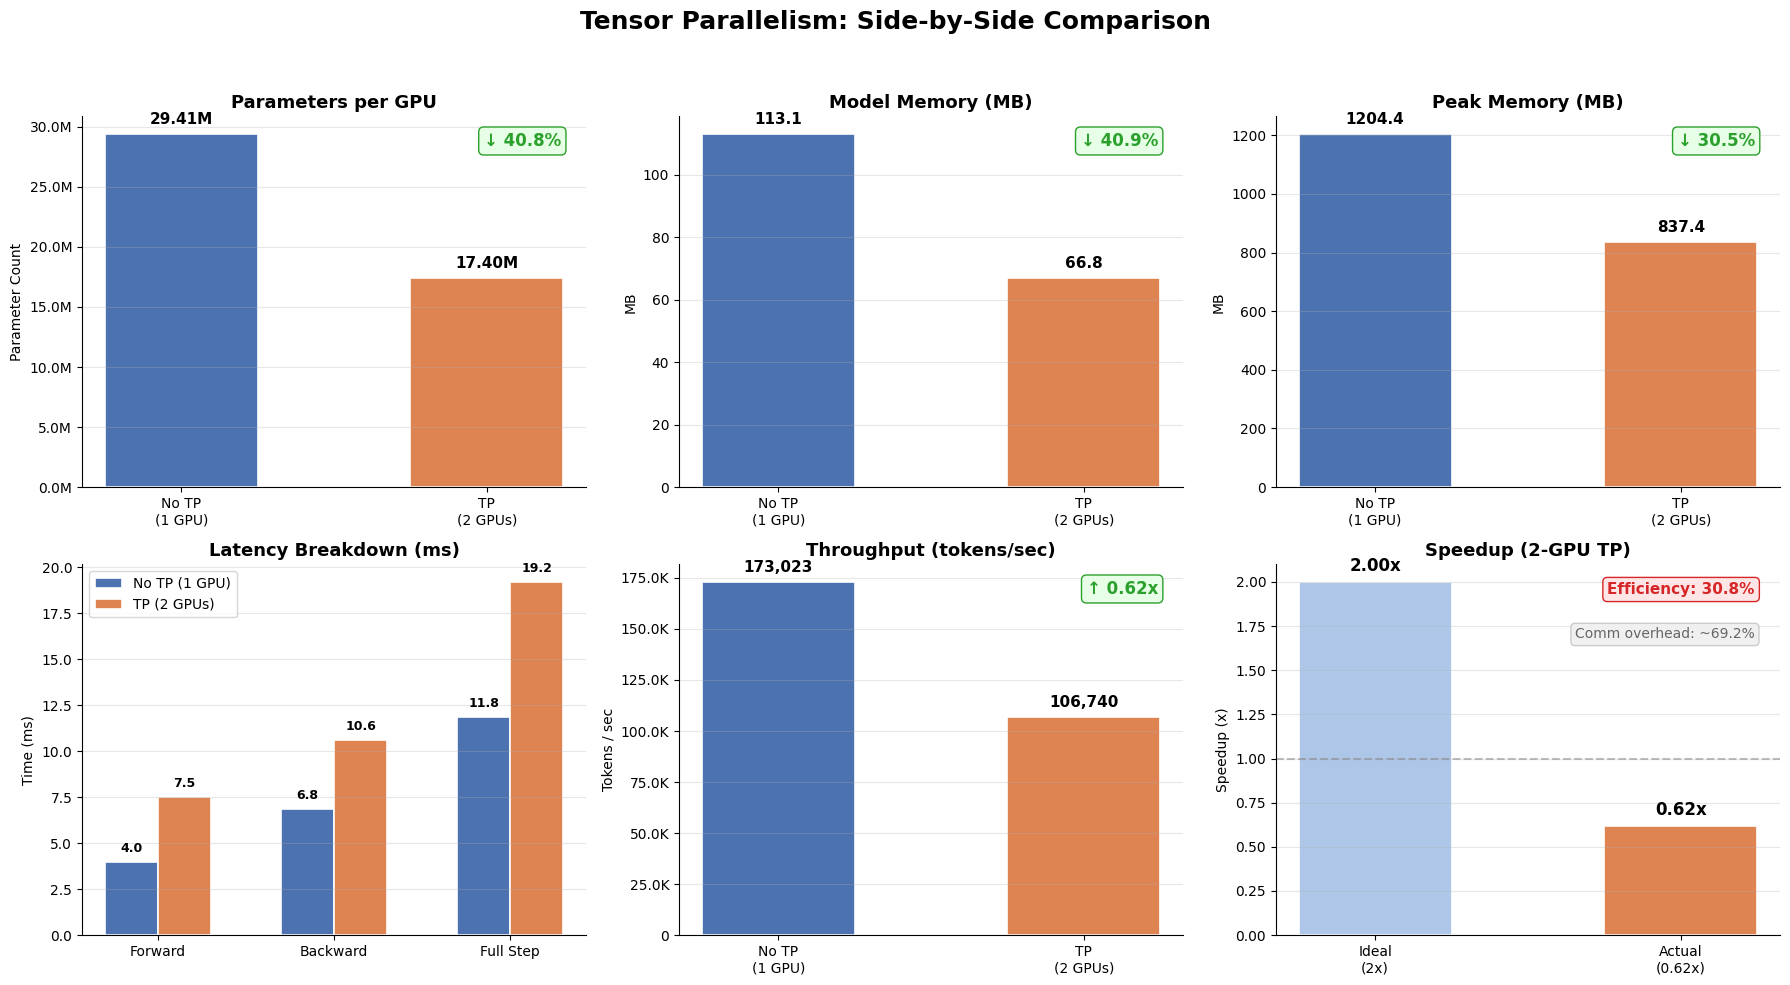


Plot saved to tp_comparison_plots.png


In [ ]:
# ================================================================
#  Part 8: Visual Comparison — Bar Charts
# ================================================================
# Paste this as a new cell after Cell 23 (or replace Cell 23)

import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Load results ---
with open('results_no_tp.json') as f: no_tp = json.load(f)
with open('results_tp.json') as f: tp = json.load(f)

ng = tp["num_gpus"]
labels_mode = [f"No TP\n(1 GPU)", f"TP\n({ng} GPUs)"]
colors = ["#4C72B0", "#DD8452"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Tensor Parallelism: Side-by-Side Comparison", fontsize=18, fontweight="bold", y=0.98)

# ── 1. Parameters per GPU ──
ax = axes[0, 0]
vals = [no_tp["params_per_gpu"], tp["params_per_gpu"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Parameters per GPU", fontsize=13, fontweight="bold")
ax.set_ylabel("Parameter Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v/1e6:.2f}M", ha="center", va="bottom", fontweight="bold", fontsize=11)
reduction = (1 - tp["params_per_gpu"] / no_tp["params_per_gpu"]) * 100
ax.text(0.95, 0.92, f"↓ {reduction:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 2. Model Memory ──
ax = axes[0, 1]
vals = [no_tp["mem_model_mb"], tp["mem_model_mb"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Model Memory (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("MB")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
reduction = (1 - tp["mem_model_mb"] / no_tp["mem_model_mb"]) * 100
ax.text(0.95, 0.92, f"↓ {reduction:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 3. Peak Memory ──
ax = axes[0, 2]
vals = [no_tp["mem_peak_mb"], tp["mem_peak_mb"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Peak Memory (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("MB")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
reduction = (1 - tp["mem_peak_mb"] / no_tp["mem_peak_mb"]) * 100
ax.text(0.95, 0.92, f"↓ {reduction:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 4. Latency Breakdown (Forward / Backward / Step) ──
ax = axes[1, 0]
x = np.arange(3)
width = 0.3
metrics = ["fwd_ms", "bwd_ms", "step_ms"]
labels_metric = ["Forward", "Backward", "Full Step"]
v_no = [no_tp[m] for m in metrics]
v_tp = [tp[m] for m in metrics]
bars1 = ax.bar(x - width/2, v_no, width, label="No TP (1 GPU)", color=colors[0], edgecolor="white", linewidth=1.2)
bars2 = ax.bar(x + width/2, v_tp, width, label=f"TP ({ng} GPUs)", color=colors[1], edgecolor="white", linewidth=1.2)
ax.set_title("Latency Breakdown (ms)", fontsize=13, fontweight="bold")
ax.set_ylabel("Time (ms)")
ax.set_xticks(x)
ax.set_xticklabels(labels_metric)
ax.legend(fontsize=10)
for bar, v in zip(list(bars1) + list(bars2), v_no + v_tp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(v_no + v_tp)*0.02,
            f"{v:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── 5. Throughput (tokens/sec) ──
ax = axes[1, 1]
vals = [no_tp["tokens_per_sec"], tp["tokens_per_sec"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Throughput (tokens/sec)", fontsize=13, fontweight="bold")
ax.set_ylabel("Tokens / sec")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.1f}K" if x >= 1000 else f"{x:.0f}"))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:,.0f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
speedup = tp["tokens_per_sec"] / no_tp["tokens_per_sec"]
ax.text(0.95, 0.92, f"↑ {speedup:.2f}x", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 6. Speedup & Efficiency ──
ax = axes[1, 2]
step_speedup = no_tp["step_ms"] / tp["step_ms"]
ideal = ng
efficiency = step_speedup / ideal * 100
x = np.arange(2)
vals = [ideal, step_speedup]
bar_labels = [f"Ideal\n({ng}x)", f"Actual\n({step_speedup:.2f}x)"]
bar_colors = ["#aec7e8", colors[1]]
bars = ax.bar(bar_labels, vals, color=bar_colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title(f"Speedup ({ng}-GPU TP)", fontsize=13, fontweight="bold")
ax.set_ylabel("Speedup (x)")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="No speedup")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:.2f}x", ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.text(0.95, 0.92, f"Efficiency: {efficiency:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=11, color="#d62728", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffe6e6", edgecolor="#d62728"))
comm_overhead = 100 - efficiency
ax.text(0.95, 0.80, f"Comm overhead: ~{comm_overhead:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=10, color="#666666",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", edgecolor="#cccccc"))

# ── Final polish ──
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("tp_comparison_plots.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("\nPlot saved to tp_comparison_plots.png")